# Figures for the Corporate Chapter of the Report SOTJ 2024

## 0. Load packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

pd.options.display.float_format = '{:,.0f}'.format
base = Path("../output/2025/tables/Final_Full_CBCR_Datasets")

## Step 1. Concatenate the final aggregate results

In [2]:
# Concatenate Final Results
sotj_aggregate_2016 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2016.csv')
sotj_aggregate_2016['MNSs'] = 'All MNEs'
sotj_aggregate_2016_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2016_USMNEs.csv')
sotj_aggregate_2016_us['MNSs'] = 'US MNEs'
sotj_aggregate_2017 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2017.csv')
sotj_aggregate_2017['MNSs'] = 'All MNEs'
sotj_aggregate_2017_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2017_USMNEs.csv')
sotj_aggregate_2017_us['MNSs'] = 'US MNEs'
sotj_aggregate_2018 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2018.csv')
sotj_aggregate_2018['MNSs'] = 'All MNEs'
sotj_aggregate_2018_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2018_USMNEs.csv')  
sotj_aggregate_2018_us['MNSs'] = 'US MNEs'
sotj_aggregate_2019 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2019.csv')
sotj_aggregate_2019['MNSs'] = 'All MNEs'
sotj_aggregate_2019_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2019_USMNEs.csv')
sotj_aggregate_2019_us['MNSs'] = 'US MNEs'
sotj_aggregate_2020 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2020.csv')
sotj_aggregate_2020['MNSs'] = 'All MNEs'
sotj_aggregate_2020_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2020_USMNEs.csv')
sotj_aggregate_2020_us['MNSs'] = 'US MNEs'
sotj_aggregate_2021 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2021.csv')
sotj_aggregate_2021['MNSs'] = 'All MNEs'
sotj_aggregate_2021_us = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2021_USMNEs.csv')
sotj_aggregate_2021_us['MNSs'] = 'US MNEs'

#Concatenate all of the above
sotj_aggregate = pd.concat([sotj_aggregate_2016, sotj_aggregate_2016_us, sotj_aggregate_2017, sotj_aggregate_2017_us, sotj_aggregate_2018, sotj_aggregate_2018_us, sotj_aggregate_2019, sotj_aggregate_2019_us, sotj_aggregate_2020, sotj_aggregate_2020_us, sotj_aggregate_2021, sotj_aggregate_2021_us])

# Export the concatenated results
sotj_aggregate = sotj_aggregate.sort_values(by=['year', 'MNSs'])
sotj_aggregate.to_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2016_2021_allMNEs_and_USMNEs.csv', index=False)

In [4]:
import pandas as pd
from pathlib import Path

base = Path("../output/2025/tables/Final_Full_CBCR_Datasets")
out_xlsx = base / "SOTJ_country_aggregates_by_year_AllAndUS.xlsx"

def load_and_aggregate(fp: Path, year: int) -> pd.DataFrame:
    df = pd.read_csv(fp)
    if "iso_partner" not in df.columns:
        raise ValueError(f"'iso_partner' column not found in {fp}")
    if "year" not in df.columns:
        df["year"] = year

    # Sum all numeric columns per year × iso_partner
    num_cols = df.select_dtypes(include="number").columns.tolist()
    group_keys = ["year", "iso_partner"]
    agg_cols = [c for c in num_cols if c not in group_keys]

    if agg_cols:
        out = df.groupby(group_keys, as_index=False)[agg_cols].sum()
    else:
        out = df[group_keys].drop_duplicates()

    # Tidy column order
    non_numeric = [c for c in out.columns if c not in agg_cols]
    return out[non_numeric + agg_cols].sort_values(["year", "iso_partner"])

with pd.ExcelWriter(out_xlsx) as writer:
    for year in range(2016, 2022):
        # All MNEs
        fp_all = base / f"SOTJ_sample_countries_{year}.csv"
        if fp_all.exists():
            df_all = load_and_aggregate(fp_all, year)
            df_all.to_excel(writer, sheet_name=f"{year}_All_MNEs", index=False)

        # US MNEs
        fp_us = base / f"SOTJ_sample_countries_{year}_USMNEs.csv"
        if fp_us.exists():
            df_us = load_and_aggregate(fp_us, year)
            df_us.to_excel(writer, sheet_name=f"{year}_US_MNEs", index=False)

print(f"Saved: {out_xlsx}")


Saved: ..\output\2025\tables\Final_Full_CBCR_Datasets\SOTJ_country_aggregates_by_year_AllAndUS.xlsx


## Step 2. Figures using the Final Aggregate Results

### Figure 1. Evolution of total profit misalignment

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_positive_misalignment'], label='Total profit misalignment')


plt.title('Evolution of total profit misalignment')
plt.xlabel('Year')
plt.ylabel('Total profit misalignment (in million USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()

NameError: name 'sotj_scaled_up' is not defined

<Figure size 1000x600 with 0 Axes>

### Figure 2. Yearly fraction of total profits shifted

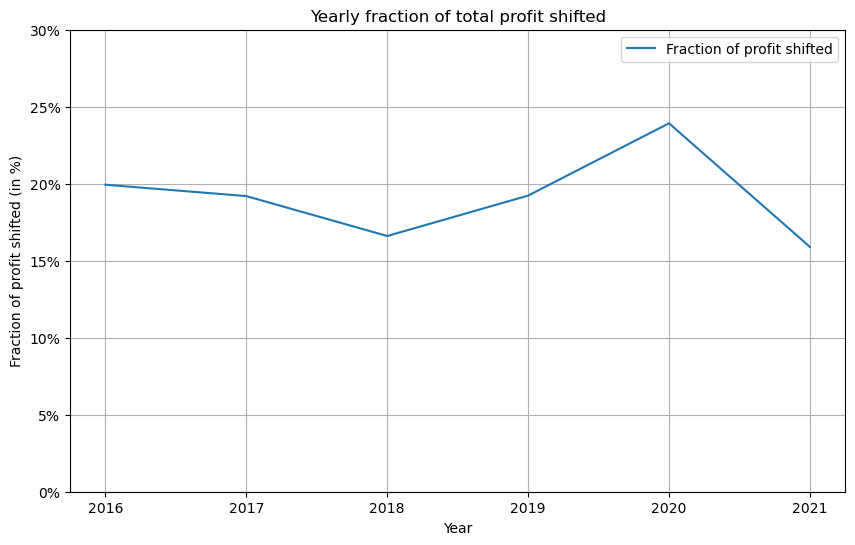

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['misaligned_of_total_profits'] * 100, label='Fraction of profits shifted')

plt.title('Yearly fraction of total profits shifted')
plt.xlabel('Year')
plt.ylabel('Fraction of profits shifted (in %)')
plt.ylim(0, 30)  # Set y-axis limits to 0 to 100%
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}%'))  # Format y-axis as percentage
plt.grid(True)
plt.show()

### Figure 3. Yearly total tax revenue losses

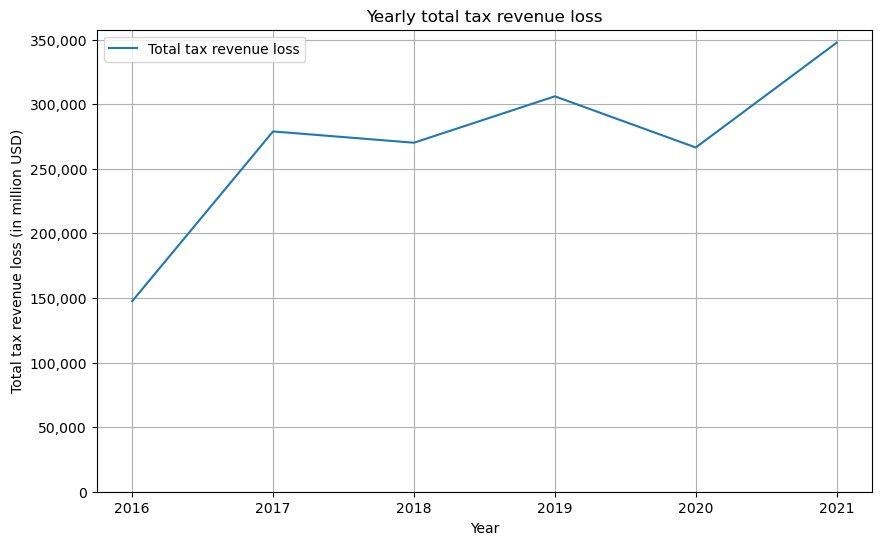

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_tax_revenue_loss'], label='Total tax revenue loss')

plt.title('Yearly total tax revenue loss')
plt.xlabel('Year')
plt.ylabel('Total tax revenue loss (in million USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()

### Figure 4. Both misalignment and tax revenue losses together

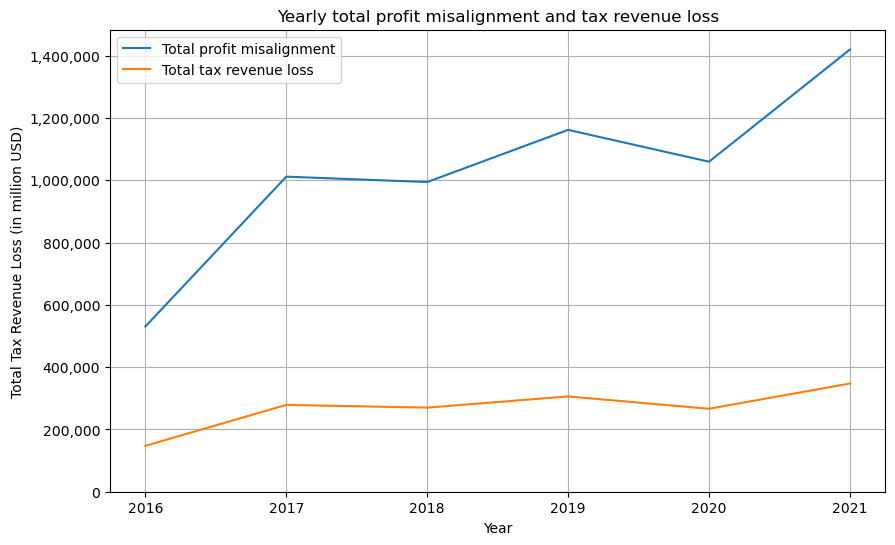

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_positive_misalignment'], label='Total profit misalignment')
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_tax_revenue_loss'], label='Total tax revenue loss')

plt.title('Yearly total profit misalignment and tax revenue loss')
plt.xlabel('Year')
plt.ylabel('Total Tax Revenue Loss (in million USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()

### Figure 5. Yearly total tax revenue gain

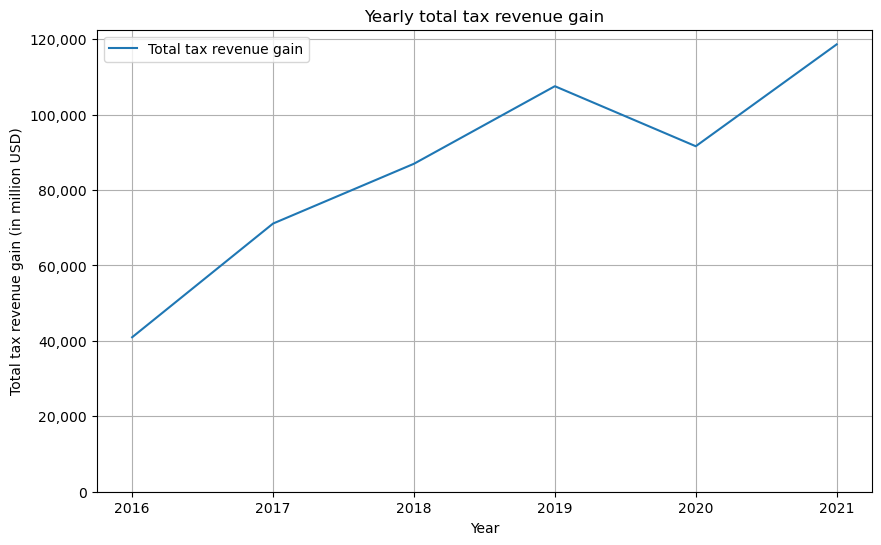

In [ ]:
plt.figure(figsize=(10, 6)) 
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_tax_revenue_gain'], label='Total tax revenue gain')

plt.title('Yearly total tax revenue gain')
plt.xlabel('Year')
plt.ylabel('Total tax revenue gain (in million USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()